
================ Portfolio Analytics ================

               Bond  FaceValue  CouponRate    YTM  Maturity  Frequency  \
0    US Treasury 5Y       1000       0.035  0.032         5          2   
1   German Bund 10Y       2000       0.020  0.023        10          1   
2  Corporate Bond A       1500       0.050  0.048         7          2   
3  Corporate Bond B       3000       0.045  0.041        12          2   
4     French OAT 8Y       2500       0.028  0.026         8          1   
5   Italian BTP 15Y       1800       0.040  0.043        15          2   

       Price  MacaulayDuration  ModifiedDuration  Convexity    DV01  Weight  
0  1013.7603            4.6333            4.5604    24.0494  0.4623  0.0854  
1  1946.9407            9.1484            8.9427    93.2632  1.7411  0.1641  
2  1517.6584            5.9987            5.8581    40.6293  0.8891  0.1279  
3  3112.8434            9.4575            9.2675   104.0768  2.8848  0.2623  
4  2535.6983            7.2836     

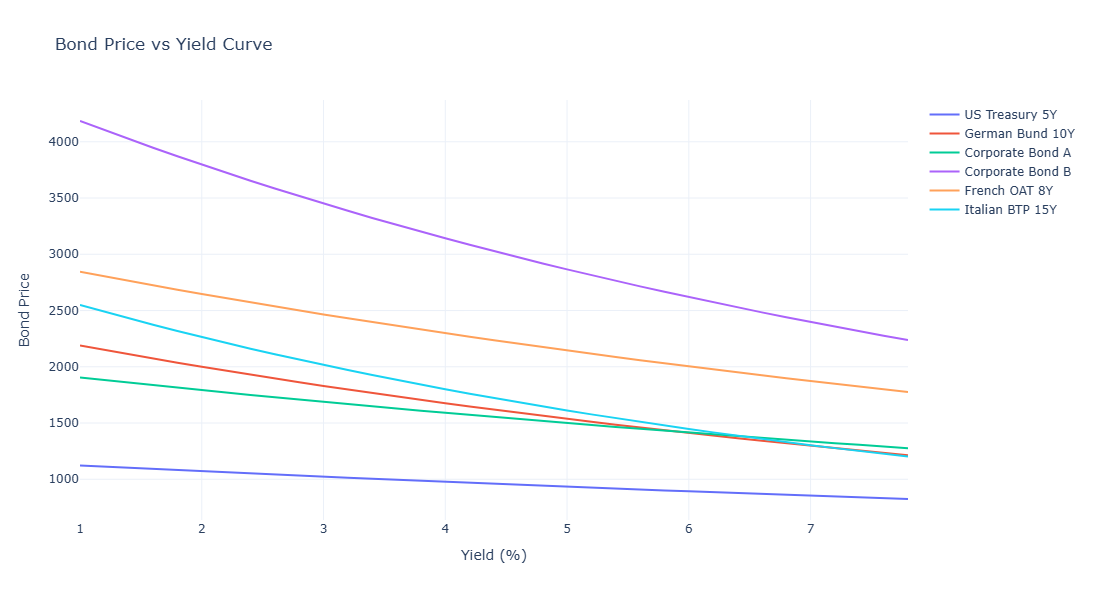

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go


####################################################
# Bond Pricing Functions
####################################################

def bond_price(face, coupon_rate, ytm, maturity, freq):

    periods = int(maturity * freq)
    coupon = face * coupon_rate / freq
    r = ytm / freq

    price = 0

    for t in range(1, periods + 1):
        price += coupon / (1 + r) ** t

    price += face / (1 + r) ** periods

    return price



def macaulay_duration(face, coupon_rate, ytm, maturity, freq):

    periods = int(maturity * freq)
    coupon = face * coupon_rate / freq
    r = ytm / freq

    price = bond_price(
        face,
        coupon_rate,
        ytm,
        maturity,
        freq
    )

    duration = 0

    for t in range(1, periods + 1):

        cashflow = coupon

        if t == periods:
            cashflow += face

        pv = cashflow / (1 + r) ** t

        duration += (t / freq) * pv

    return duration / price



def modified_duration(face, coupon_rate, ytm, maturity, freq):

    mac = macaulay_duration(
        face,
        coupon_rate,
        ytm,
        maturity,
        freq
    )

    return mac / (1 + ytm / freq)



def convexity(face, coupon_rate, ytm, maturity, freq):

    periods = int(maturity * freq)

    coupon = face * coupon_rate / freq

    r = ytm / freq

    price = bond_price(
        face,
        coupon_rate,
        ytm,
        maturity,
        freq
    )

    conv = 0

    for t in range(1, periods + 1):

        cashflow = coupon

        if t == periods:
            cashflow += face

        pv = cashflow / (1 + r) ** t

        conv += pv * t * (t + 1)

    conv = conv / (
        price *
        (1 + r) ** 2 *
        freq ** 2
    )

    return conv



def dv01(face, coupon_rate, ytm, maturity, freq):

    md = modified_duration(
        face,
        coupon_rate,
        ytm,
        maturity,
        freq
    )

    price = bond_price(
        face,
        coupon_rate,
        ytm,
        maturity,
        freq
    )

    return md * price * 0.0001



####################################################
# Example Bond Portfolio
####################################################

portfolio = pd.DataFrame({

    "Bond": [
        "US Treasury 5Y",
        "German Bund 10Y",
        "Corporate Bond A",
        "Corporate Bond B",
        "French OAT 8Y",
        "Italian BTP 15Y"
    ],

    "FaceValue": [
        1000,
        2000,
        1500,
        3000,
        2500,
        1800
    ],

    "CouponRate": [
        0.035,
        0.020,
        0.050,
        0.045,
        0.028,
        0.040
    ],

    "YTM": [
        0.032,
        0.023,
        0.048,
        0.041,
        0.026,
        0.043
    ],

    "Maturity": [
        5,
        10,
        7,
        12,
        8,
        15
    ],

    "Frequency": [
        2,
        1,
        2,
        2,
        1,
        2
    ]
})


####################################################
# Bond Analytics Calculation
####################################################

prices = []
macs = []
mods = []
convs = []
dv01s = []


for _, bond in portfolio.iterrows():

    face = bond["FaceValue"]
    coupon = bond["CouponRate"]
    ytm = bond["YTM"]
    maturity = bond["Maturity"]
    freq = bond["Frequency"]

    prices.append(
        bond_price(
            face,
            coupon,
            ytm,
            maturity,
            freq
        )
    )

    macs.append(
        macaulay_duration(
            face,
            coupon,
            ytm,
            maturity,
            freq
        )
    )

    mods.append(
        modified_duration(
            face,
            coupon,
            ytm,
            maturity,
            freq
        )
    )

    convs.append(
        convexity(
            face,
            coupon,
            ytm,
            maturity,
            freq
        )
    )

    dv01s.append(
        dv01(
            face,
            coupon,
            ytm,
            maturity,
            freq
        )
    )


portfolio["Price"] = prices
portfolio["MacaulayDuration"] = macs
portfolio["ModifiedDuration"] = mods
portfolio["Convexity"] = convs
portfolio["DV01"] = dv01s



####################################################
# Portfolio Statistics
####################################################

portfolio["Weight"] = (
    portfolio["Price"] /
    portfolio["Price"].sum()
)


portfolio_duration = np.sum(
    portfolio["Weight"] *
    portfolio["ModifiedDuration"]
)


portfolio_convexity = np.sum(
    portfolio["Weight"] *
    portfolio["Convexity"]
)


market_value = portfolio["Price"].sum()



print("\n================ Portfolio Analytics ================\n")

print(portfolio.round(4))

print(
    "\nPortfolio Market Value : {:.2f}"
    .format(market_value)
)

print(
    "Portfolio Duration     : {:.4f}"
    .format(portfolio_duration)
)

print(
    "Portfolio Convexity    : {:.4f}"
    .format(portfolio_convexity)
)



####################################################
# Interest Rate Scenario Analysis
####################################################

print("\n================ Scenario Analysis ================\n")


scenarios = [
    -0.005,
    -0.0025,
    0,
    0.0025,
    0.005,
    0.01
]


for shift in scenarios:

    new_value = 0

    for _, bond in portfolio.iterrows():

        price = bond_price(
            bond["FaceValue"],
            bond["CouponRate"],
            bond["YTM"] + shift,
            bond["Maturity"],
            bond["Frequency"]
        )

        new_value += price


    change = new_value - market_value


    print(
        f"Yield Shift {shift*100:+.2f}% | "
        f"Portfolio Value = {new_value:,.2f} | "
        f"Gain/Loss = {change:,.2f}"
    )



####################################################
# Interactive Price-Yield Curves Using Plotly
####################################################


yield_range = np.arange(
    0.01,
    0.08,
    0.002
)


fig = go.Figure()



for _, bond in portfolio.iterrows():

    prices = []

    for y in yield_range:

        prices.append(
            bond_price(
                bond["FaceValue"],
                bond["CouponRate"],
                y,
                bond["Maturity"],
                bond["Frequency"]
            )
        )


    fig.add_trace(
        go.Scatter(
            x=yield_range * 100,
            y=prices,
            mode="lines",
            name=bond["Bond"]
        )
    )



fig.update_layout(
    title="Bond Price vs Yield Curve",
    xaxis_title="Yield (%)",
    yaxis_title="Bond Price",
    template="plotly_white",
    width=1000,
    height=600)


fig.show()